In [39]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# ============================================
#  IMPORT TUNING AND SHAP LIBRARIES
# ============================================

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint
import shap

import sys
import os

# Add Scripts folder to path
sys.path.append(os.path.abspath("../Scripts"))

from data_populator import RangeDataPopulator


In [13]:
# ============================================
# 2. DISPLAY SETTINGS AND REPRODUCIBILITY
# ============================================

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

sns.set_style("whitegrid")

RANDOM_STATE = 42

In [14]:
# Load original dataset
df_original = pd.read_csv("../data/processed/crop_clean.csv", dtype=str)
print("Original rows: ", len(df_original))

Original rows:  288


In [15]:
# ==========================================================
# Initialize Populator
# ==========================================================

n_samples_per_row = 200
decimal_precision = 2

populator = RangeDataPopulator(
    n_samples=n_samples_per_row,
    decimal_places=decimal_precision
)

df = populator.populate(df_original)

print("Original rows:", len(df_original))
print("Populated rows:", len(df))


Original rows: 288
Populated rows: 57600


In [16]:

print("Original rows:", len(df_original))
print("Populated rows:", len(df))

df.info()
df.isna().sum()

Original rows: 288
Populated rows: 57600
<class 'pandas.DataFrame'>
RangeIndex: 57600 entries, 0 to 57599
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   N (kg/ha)     57600 non-null  float64
 1   P (kg/ha)     57600 non-null  float64
 2   K (kg/ha)     57600 non-null  float64
 3   T (°C)        57600 non-null  float64
 4   PH            57600 non-null  float64
 5   RF (mm)       57600 non-null  float64
 6   Altitude (m)  57600 non-null  float64
 7   LGP           57600 non-null  float64
 8   Crop Type     57600 non-null  str    
 9   Crop Species  57600 non-null  str    
 10  Yield (q/ha)  57600 non-null  float64
dtypes: float64(9), str(2)
memory usage: 5.8 MB


N (kg/ha)       0
P (kg/ha)       0
K (kg/ha)       0
T (°C)          0
PH              0
RF (mm)         0
Altitude (m)    0
LGP             0
Crop Type       0
Crop Species    0
Yield (q/ha)    0
dtype: int64

In [17]:
# Load dataset
df = pd.read_csv("../data/processed/cereal_populated_data.csv")

# Preview the data
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (57600, 11)


,N (kg/ha),P (kg/ha),K (kg/ha),T (°C),PH,RF (mm),Altitude (m),LGP,Crop Type,Crop Species,Yield (q/ha)
0,75.59,24.27,16.66,25.12,6.85,878.94,2130.65,98.49,Teff,Acc 236756-3 (Bir Adama),17.49
1,91.88,25.78,19.22,10.34,6.25,1245.58,2364.32,111.72,Teff,Acc 236756-3 (Bir Adama),17.03
2,71.31,10.00,21.33,18.63,5.87,784.42,1904.52,106.16,Teff,Acc 236756-3 (Bir Adama),16.14
3,76.17,15.03,19.30,17.77,6.10,941.96,1893.22,99.55,Teff,Acc 236756-3 (Bir Adama),16.02
4,75.01,10.60,24.80,13.50,5.98,775.83,1802.76,99.69,Teff,Acc 236756-3 (Bir Adama),17.99


In [18]:
# ============================================
# 4. INSPECT DATASET STRUCTURE
# ============================================

print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Columns:
['N (kg/ha)', 'P (kg/ha)', 'K (kg/ha)', 'T (°C)', 'PH', 'RF (mm)', 'Altitude (m)', 'LGP', 'Crop Type', 'Crop Species', 'Yield (q/ha)']

Data types:
N (kg/ha)       float64
P (kg/ha)       float64
K (kg/ha)       float64
T (°C)          float64
PH              float64
RF (mm)         float64
Altitude (m)    float64
LGP             float64
Crop Type           str
Crop Species        str
Yield (q/ha)    float64
dtype: object

Missing values:
N (kg/ha)       0
P (kg/ha)       0
K (kg/ha)       0
T (°C)          0
PH              0
RF (mm)         0
Altitude (m)    0
LGP             0
Crop Type       0
Crop Species    0
Yield (q/ha)    0
dtype: int64


In [20]:
# ============================================
# 5. DEFINE FEATURES AND TARGET
# ============================================

feature_cols = [
    "N (kg/ha)",
    "P (kg/ha)",
    "K (kg/ha)",
    "T (°C)",
    "PH",
    "RF (mm)",
    "Altitude (m)",
    "LGP"
]

target_col = "Crop Type"

X = df[feature_cols].copy()
y = df[target_col].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nCrop Type distribution:")
print(y.value_counts())

Feature matrix shape: (57600, 8)
Target shape: (57600,)

Crop Type distribution:
Crop Type
Wheat      19000
Sorghum    10800
Maize      10200
Barley      9000
Teff        8600
Name: count, dtype: int64


In [21]:
# ============================================
# 6. ENCODE TARGET LABELS
# ============================================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

label_mapping = pd.DataFrame({
    "Crop Type": label_encoder.classes_,
    "Encoded Label": range(len(label_encoder.classes_))
})

label_mapping

,Crop Type,Encoded Label
0,Barley,0
1,Maize,1
2,Sorghum,2
3,Teff,3
4,Wheat,4


In [22]:
# ============================================
# 7. TRAIN-TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (46080, 8)
X_test shape : (11520, 8)
y_train shape: (46080,)
y_test shape : (11520,)


In [23]:
# ============================================
# 8. PREPROCESSING PIPELINE
# ============================================

numeric_features = [
    "N (kg/ha)",
    "P (kg/ha)",
    "K (kg/ha)",
    "T (°C)",
    "PH",
    "RF (mm)",
    "Altitude (m)",
    "LGP"
]

numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_na

In [24]:
# ============================================
# 9. EVALUATION FUNCTION
# ============================================

def evaluate_model(model_name, pipeline, X_train, X_test, y_train, y_test, results_dict, plot_cm=False):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    cm = confusion_matrix(y_test, y_pred)

    print(f"\n===== {model_name} =====")
    print(f"Accuracy        : {acc:.4f}")
    print(f"Precision       : {prec:.4f}")
    print(f"Recall          : {rec:.4f}")
    print(f"Macro F1        : {f1_macro:.4f}")
    print(f"Weighted F1     : {f1_weighted:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("\nConfusion Matrix:")
    print(cm)

    # # Uncomment only when you want to plot confusion matrix
    # if plot_cm:
    #     plt.figure(figsize=(8, 6))
    #     sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    #     plt.title(f"{model_name} - Confusion Matrix")
    #     plt.xlabel("Predicted")
    #     plt.ylabel("Actual")
    #     plt.show()

    results_dict[model_name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Macro F1": f1_macro,
        "Weighted F1": f1_weighted
    }

In [25]:
# ============================================
# 10. RESULTS STORAGE
# ============================================

results_dict = {}

In [26]:
# ============================================
# 11. LOGISTIC REGRESSION
# ============================================

log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        C=1.0,
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

evaluate_model(
    model_name="Logistic Regression",
    pipeline=log_reg_pipeline,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    results_dict=results_dict,
    plot_cm=False
)


===== Logistic Regression =====
Accuracy        : 0.9655
Precision       : 0.9654
Recall          : 0.9655
Macro F1        : 0.9633
Weighted F1     : 0.9652

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1800
           1       0.96      0.91      0.93      2040
           2       1.00      1.00      1.00      2160
           3       0.93      0.90      0.91      1720
           4       0.95      0.99      0.97      3800

    accuracy                           0.97     11520
   macro avg       0.97      0.96      0.96     11520
weighted avg       0.97      0.97      0.97     11520


Confusion Matrix:
[[1800    0    0    0    0]
 [   0 1858    3   95   84]
 [   0    1 2159    0    0]
 [   0   60    1 1546  113]
 [   0   21    0   20 3759]]


In [27]:
# ============================================
# 12. K-NEAREST NEIGHBORS
# ============================================

knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(
        n_neighbors=5,
        weights="uniform",
        metric="minkowski",
        p=2
    ))
])

evaluate_model(
    model_name="KNN",
    pipeline=knn_pipeline,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    results_dict=results_dict,
    plot_cm=False
)


===== KNN =====
Accuracy        : 0.9837
Precision       : 0.9838
Recall          : 0.9837
Macro F1        : 0.9838
Weighted F1     : 0.9837

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1800
           1       0.99      0.96      0.97      2040
           2       1.00      1.00      1.00      2160
           3       0.97      0.97      0.97      1720
           4       0.97      0.99      0.98      3800

    accuracy                           0.98     11520
   macro avg       0.99      0.98      0.98     11520
weighted avg       0.98      0.98      0.98     11520


Confusion Matrix:
[[1800    0    0    0    0]
 [   0 1950    6   29   55]
 [   0    3 2156    1    0]
 [   0    4    0 1661   55]
 [   0   11    0   24 3765]]


In [28]:
# ============================================
# 13. DECISION TREE
# ============================================

decision_tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="gini",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=RANDOM_STATE
    ))
])

evaluate_model(
    model_name="Decision Tree",
    pipeline=decision_tree_pipeline,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    results_dict=results_dict,
    plot_cm=False
)


===== Decision Tree =====
Accuracy        : 0.9974
Precision       : 0.9974
Recall          : 0.9974
Macro F1        : 0.9971
Weighted F1     : 0.9974

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1800
           1       0.99      0.99      0.99      2040
           2       1.00      1.00      1.00      2160
           3       0.99      0.99      0.99      1720
           4       1.00      1.00      1.00      3800

    accuracy                           1.00     11520
   macro avg       1.00      1.00      1.00     11520
weighted avg       1.00      1.00      1.00     11520


Confusion Matrix:
[[1800    0    0    0    0]
 [   0 2025    0   10    5]
 [   0    0 2160    0    0]
 [   0   11    0 1708    1]
 [   0    3    0    0 3797]]


In [29]:
# ============================================
# 14. RANDOM FOREST
# ============================================

random_forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        criterion="gini",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

evaluate_model(
    model_name="Random Forest",
    pipeline=random_forest_pipeline,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    results_dict=results_dict,
    plot_cm=False
)


===== Random Forest =====
Accuracy        : 0.9986
Precision       : 0.9986
Recall          : 0.9986
Macro F1        : 0.9985
Weighted F1     : 0.9986

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1800
           1       1.00      0.99      1.00      2040
           2       1.00      1.00      1.00      2160
           3       0.99      1.00      1.00      1720
           4       1.00      1.00      1.00      3800

    accuracy                           1.00     11520
   macro avg       1.00      1.00      1.00     11520
weighted avg       1.00      1.00      1.00     11520


Confusion Matrix:
[[1800    0    0    0    0]
 [   0 2026    0    9    5]
 [   0    0 2160    0    0]
 [   0    1    0 1718    1]
 [   0    0    0    0 3800]]


In [30]:
# ============================================
# 15. SUPPORT VECTOR MACHINE
# ============================================

svm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(
        C=1.0,
        kernel="rbf",
        gamma="scale",
        probability=False,
        random_state=RANDOM_STATE
    ))
])

evaluate_model(
    model_name="SVM",
    pipeline=svm_pipeline,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    results_dict=results_dict,
    plot_cm=False
)


===== SVM =====
Accuracy        : 0.9945
Precision       : 0.9946
Recall          : 0.9945
Macro F1        : 0.9942
Weighted F1     : 0.9945

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1800
           1       1.00      0.98      0.99      2040
           2       1.00      1.00      1.00      2160
           3       0.98      0.99      0.99      1720
           4       0.99      1.00      1.00      3800

    accuracy                           0.99     11520
   macro avg       0.99      0.99      0.99     11520
weighted avg       0.99      0.99      0.99     11520


Confusion Matrix:
[[1800    0    0    0    0]
 [   0 1999    1   23   17]
 [   0    1 2159    0    0]
 [   0    4    0 1705   11]
 [   0    2    0    4 3794]]


In [33]:
# ============================================
# 16. GAUSSIAN NAIVE BAYES
# ============================================

naive_bayes_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GaussianNB(
        var_smoothing=1e-9
    ))
])

evaluate_model(
    model_name="Gaussian Naive Bayes",
    pipeline=naive_bayes_pipeline,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    results_dict=results_dict,
    plot_cm=False
)


===== Gaussian Naive Bayes =====
Accuracy        : 0.9883
Precision       : 0.9884
Recall          : 0.9883
Macro F1        : 0.9879
Weighted F1     : 0.9882

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1800
           1       0.99      0.97      0.98      2040
           2       1.00      1.00      1.00      2160
           3       0.98      0.96      0.97      1720
           4       0.98      1.00      0.99      3800

    accuracy                           0.99     11520
   macro avg       0.99      0.99      0.99     11520
weighted avg       0.99      0.99      0.99     11520


Confusion Matrix:
[[1800    0    0    0    0]
 [   0 1970    8   28   34]
 [   0    0 2160    0    0]
 [   0   10    0 1656   54]
 [   0    0    0    1 3799]]


In [34]:
# ============================================
# 17. GRADIENT BOOSTING
# ============================================

gradient_boosting_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=RANDOM_STATE
    ))
])

evaluate_model(
    model_name="Gradient Boosting",
    pipeline=gradient_boosting_pipeline,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    results_dict=results_dict,
    plot_cm=False
)


===== Gradient Boosting =====
Accuracy        : 0.9984
Precision       : 0.9984
Recall          : 0.9984
Macro F1        : 0.9982
Weighted F1     : 0.9983

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1800
           1       1.00      0.99      1.00      2040
           2       1.00      1.00      1.00      2160
           3       0.99      1.00      1.00      1720
           4       1.00      1.00      1.00      3800

    accuracy                           1.00     11520
   macro avg       1.00      1.00      1.00     11520
weighted avg       1.00      1.00      1.00     11520


Confusion Matrix:
[[1800    0    0    0    0]
 [   0 2022    0   12    6]
 [   0    0 2160    0    0]
 [   0    0    0 1719    1]
 [   0    0    0    0 3800]]


In [35]:
# ============================================
# 18. BASELINE MODEL COMPARISON
# ============================================

results_df = pd.DataFrame(results_dict).T.reset_index()
results_df = results_df.rename(columns={"index": "Model"})
results_df = results_df.sort_values(by="Weighted F1", ascending=False).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,Macro F1,Weighted F1
0,Random Forest,0.998611,0.998615,0.998611,0.998466,0.998610
1,Gradient Boosting,0.998351,0.998358,0.998351,0.998176,0.998349
2,Decision Tree,0.997396,0.997395,0.997396,0.997062,0.997395
3,SVM,0.994531,0.994551,0.994531,0.994209,0.994524
4,Gaussian Naive Bayes,0.988281,0.988376,0.988281,0.987872,0.988232
5,KNN,0.983681,0.983795,0.983681,0.983790,0.983651
6,Logistic Regression,0.965451,0.965405,0.965451,0.963270,0.965153


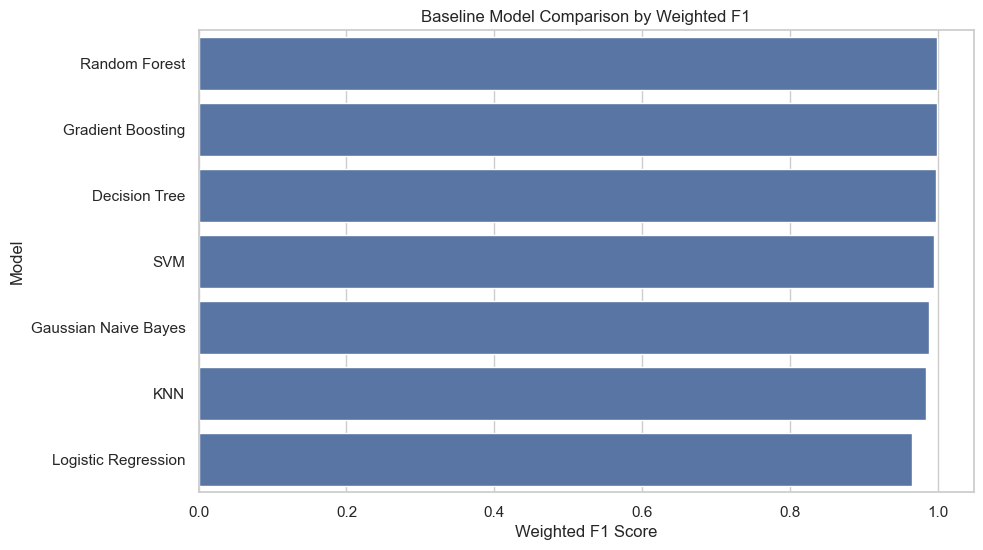

In [36]:
# ============================================
# 19. BASELINE PERFORMANCE PLOT
# ============================================

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Weighted F1", y="Model")
plt.title("Baseline Model Comparison by Weighted F1")
plt.xlabel("Weighted F1 Score")
plt.ylabel("Model")
plt.show()

In [37]:
# ============================================
# 20. CROSS-VALIDATION FUNCTION
# ============================================

def evaluate_with_cross_validation(model_name, pipeline, X_train, y_train, cv=5, scoring="f1_weighted"):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=skf,
        scoring=scoring,
        n_jobs=-1
    )

    print(f"\n===== {model_name} Cross-Validation =====")
    print(f"{scoring} scores: {scores}")
    print(f"Mean {scoring}: {scores.mean():.4f}")
    print(f"Std  {scoring}: {scores.std():.4f}")

    return scores

In [38]:
# ============================================
# 21. CROSS-VALIDATION FOR SHORTLISTED MODELS
# ============================================

# Example shortlist:
# Update these names after seeing your baseline results
shortlisted_models = {
    "Random Forest": random_forest_pipeline,
    "SVM": svm_pipeline,
    "Gradient Boosting": gradient_boosting_pipeline
}

cv_results = {}

for model_name, pipeline in shortlisted_models.items():
    scores = evaluate_with_cross_validation(
        model_name=model_name,
        pipeline=pipeline,
        X_train=X_train,
        y_train=y_train,
        cv=5,
        scoring="f1_weighted"
    )
    cv_results[model_name] = {
        "CV Mean Weighted F1": scores.mean(),
        "CV Std Weighted F1": scores.std()
    }

cv_results_df = pd.DataFrame(cv_results).T.reset_index()
cv_results_df = cv_results_df.rename(columns={"index": "Model"})
cv_results_df = cv_results_df.sort_values(by="CV Mean Weighted F1", ascending=False).reset_index(drop=True)

cv_results_df


===== Random Forest Cross-Validation =====
f1_weighted scores: [0.99848017 0.99858875 0.99837117 0.99858866 0.99934903]
Mean f1_weighted: 0.9987
Std  f1_weighted: 0.0003

===== SVM Cross-Validation =====
f1_weighted scores: [0.9933653  0.9933679  0.99424168 0.99293264 0.9929325 ]
Mean f1_weighted: 0.9934
Std  f1_weighted: 0.0005

===== Gradient Boosting Cross-Validation =====
f1_weighted scores: [0.9980451  0.99847992 0.99826209 0.99869717 0.99924056]
Mean f1_weighted: 0.9985
Std  f1_weighted: 0.0004


,Model,CV Mean Weighted F1,CV Std Weighted F1
0,Random Forest,0.998676,0.000346
1,Gradient Boosting,0.998545,0.000410
2,SVM,0.993368,0.000478


# ============================================
# HYPERPARAMETER TUNING
# ============================================

In [42]:
# ============================================
# 22. RANDOMIZED SEARCH CV - RANDOM FOREST
# ============================================

rf_random_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_random_param_dist = {
    "classifier__n_estimators": randint(100, 105),
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": randint(2, 3),
    "classifier__min_samples_leaf": randint(1, 2),
    "classifier__criterion": ["gini", "entropy", "log_loss"],
    "classifier__max_features": ["sqrt", "log2", None]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_random_pipeline,
    param_distributions=rf_random_param_dist,
    n_iter=25,
    scoring="f1_weighted",
    cv=5,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)

print("Best Randomized Search Score:", rf_random_search.best_score_)
print("\nBest Randomized Search Parameters:")
print(rf_random_search.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Randomized Search Score: 0.9986972104870151

Best Randomized Search Parameters:
{'classifier__criterion': 'log_loss', 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 103}


In [45]:
# ============================================
# 23. GRID SEARCH CV - RANDOM FOREST
# ============================================

rf_grid_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_grid_param_grid = {
    "classifier__n_estimators": [100],
    "classifier__max_depth": [None, 10],
    "classifier__min_samples_split": [2],
    "classifier__min_samples_leaf": [1],
    "classifier__criterion": ["gini", "entropy"]
}

rf_grid_search = GridSearchCV(
    estimator=rf_grid_pipeline,
    param_grid=rf_grid_param_grid,
    scoring="f1_weighted",
    cv=5,
    verbose=1,
    n_jobs=-1
)

rf_grid_search.fit(X_train, y_train)

print("Best Grid Search Score:", rf_grid_search.best_score_)
print("\nBest Grid Search Parameters:")
print(rf_grid_search.best_params_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Grid Search Score: 0.9986754995274805

Best Grid Search Parameters:
{'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


In [47]:
# ============================================
# 24. SELECT BEST TUNED RANDOM FOREST MODEL
# ============================================

if rf_grid_search.best_score_ >= rf_random_search.best_score_:
    best_rf_model = rf_grid_search.best_estimator_
    best_rf_search_name = "Grid Search Random Forest"
    best_rf_cv_score = rf_grid_search.best_score_
    best_rf_params = rf_grid_search.best_params_
else:
    best_rf_model = rf_random_search.best_estimator_
    best_rf_search_name = "Randomized Search Random Forest"
    best_rf_cv_score = rf_random_search.best_score_
    best_rf_params = rf_random_search.best_params_

print("Selected Best Tuned Model:", best_rf_search_name)
print("Best CV Weighted F1:", best_rf_cv_score)
print("\nSelected Parameters:")
print(best_rf_params)

Selected Best Tuned Model: Randomized Search Random Forest
Best CV Weighted F1: 0.9986972104870151

Selected Parameters:
{'classifier__criterion': 'log_loss', 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 103}


In [48]:
# ============================================
# 25. EVALUATE BEST TUNED RANDOM FOREST
# ============================================

evaluate_model(
    model_name=best_rf_search_name,
    pipeline=best_rf_model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    results_dict=results_dict,
    plot_cm=True
)


===== Randomized Search Random Forest =====
Accuracy        : 0.9986
Precision       : 0.9986
Recall          : 0.9986
Macro F1        : 0.9985
Weighted F1     : 0.9986

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1800
           1       1.00      0.99      1.00      2040
           2       1.00      1.00      1.00      2160
           3       0.99      1.00      1.00      1720
           4       1.00      1.00      1.00      3800

    accuracy                           1.00     11520
   macro avg       1.00      1.00      1.00     11520
weighted avg       1.00      1.00      1.00     11520


Confusion Matrix:
[[1800    0    0    0    0]
 [   0 2025    0   10    5]
 [   0    0 2160    0    0]
 [   0    0    0 1719    1]
 [   0    0    0    0 3800]]


In [50]:
# ============================================
# 26. COMPARE BASELINE VS TUNED RANDOM FOREST
# ============================================

comparison_rows = []

if "Random Forest" in results_dict:
    baseline_rf = results_dict["Random Forest"]
    comparison_rows.append({
        "Model Version": "Baseline Random Forest",
        "Accuracy": baseline_rf["Accuracy"],
        "Precision": baseline_rf["Precision"],
        "Recall": baseline_rf["Recall"],
        "Macro F1": baseline_rf["Macro F1"],
        "Weighted F1": baseline_rf["Weighted F1"]
    })

if best_rf_search_name in results_dict:
    tuned_rf = results_dict[best_rf_search_name]
    comparison_rows.append({
        "Model Version": best_rf_search_name,
        "Accuracy": tuned_rf["Accuracy"],
        "Precision": tuned_rf["Precision"],
        "Recall": tuned_rf["Recall"],
        "Macro F1": tuned_rf["Macro F1"],
        "Weighted F1": tuned_rf["Weighted F1"]
    })

rf_comparison_df = pd.DataFrame(comparison_rows)
rf_comparison_df

,Model Version,Accuracy,Precision,Recall,Macro F1,Weighted F1
0,Baseline Random Forest,0.998611,0.998615,0.998611,0.998466,0.99861
1,Randomized Search Random Forest,0.998611,0.998616,0.998611,0.998466,0.99861


In [51]:
# ============================================
# 27. SHAP ANALYSIS - FINAL RANDOM FOREST
# ============================================

# Fit the final model if not already fitted
best_rf_model.fit(X_train, y_train)

# Transform the training and test data using the fitted preprocessor
X_train_transformed = best_rf_model.named_steps["preprocessor"].transform(X_train)
X_test_transformed = best_rf_model.named_steps["preprocessor"].transform(X_test)

# Get transformed feature names
feature_names = best_rf_model.named_steps["preprocessor"].get_feature_names_out()

# Convert transformed arrays to DataFrame for readability
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# Extract the trained classifier
rf_classifier = best_rf_model.named_steps["classifier"]

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_classifier)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_transformed_df)

print("SHAP analysis completed.")
print("Feature names used in SHAP:")
print(list(feature_names))

SHAP analysis completed.
Feature names used in SHAP:
['num__N (kg/ha)', 'num__P (kg/ha)', 'num__K (kg/ha)', 'num__T (°C)', 'num__PH', 'num__RF (mm)', 'num__Altitude (m)', 'num__LGP']


Displaying SHAP summary plot for class: Barley


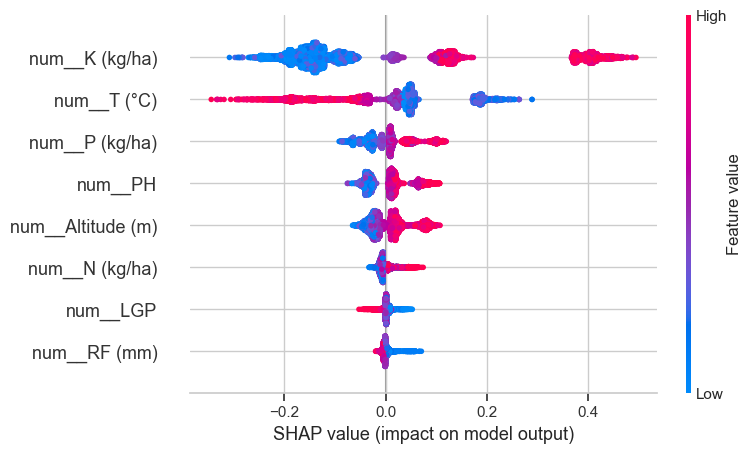

In [52]:
# ============================================
# 28. SHAP SUMMARY PLOT
# ============================================

# For multiclass classification, SHAP may return a list or a 3D array depending on version.
# The following block handles both cases.

if isinstance(shap_values, list):
    # Plot SHAP summary for the first class as an example
    class_index = 0
    print(f"Displaying SHAP summary plot for class: {label_encoder.classes_[class_index]}")
    shap.summary_plot(
        shap_values[class_index],
        X_test_transformed_df,
        feature_names=feature_names
    )
else:
    # If SHAP returns a 3D array: (samples, features, classes)
    if len(shap_values.shape) == 3:
        class_index = 0
        print(f"Displaying SHAP summary plot for class: {label_encoder.classes_[class_index]}")
        shap.summary_plot(
            shap_values[:, :, class_index],
            X_test_transformed_df,
            feature_names=feature_names
        )
    else:
        shap.summary_plot(
            shap_values,
            X_test_transformed_df,
            feature_names=feature_names
        )

In [53]:
# ============================================
# 29. SHAP FEATURE IMPORTANCE TABLE
# ============================================

if isinstance(shap_values, list):
    shap_array = np.abs(np.array(shap_values)).mean(axis=0)
    if len(shap_array.shape) == 2:
        mean_abs_shap = shap_array.mean(axis=1)
    else:
        mean_abs_shap = shap_array
elif len(shap_values.shape) == 3:
    mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))
else:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP Value|": mean_abs_shap
}).sort_values(by="Mean |SHAP Value|", ascending=False).reset_index(drop=True)

shap_importance_df

,Feature,Mean |SHAP Value|
0,num__K (kg/ha),0.156729
1,num__T (°C),0.072264
2,num__N (kg/ha),0.069894
3,num__P (kg/ha),0.048933
4,num__Altitude (m),0.023786
5,num__LGP,0.023566
6,num__PH,0.016228
7,num__RF (mm),0.005409


Displaying SHAP summary plot for class: Barley


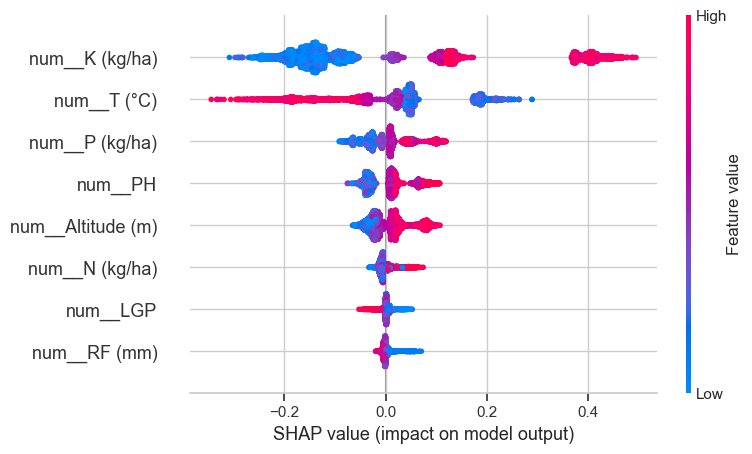

Displaying SHAP summary plot for class: Maize


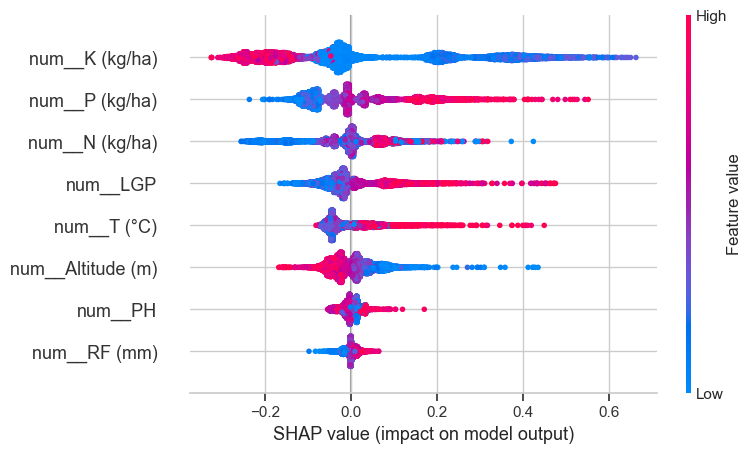

Displaying SHAP summary plot for class: Sorghum


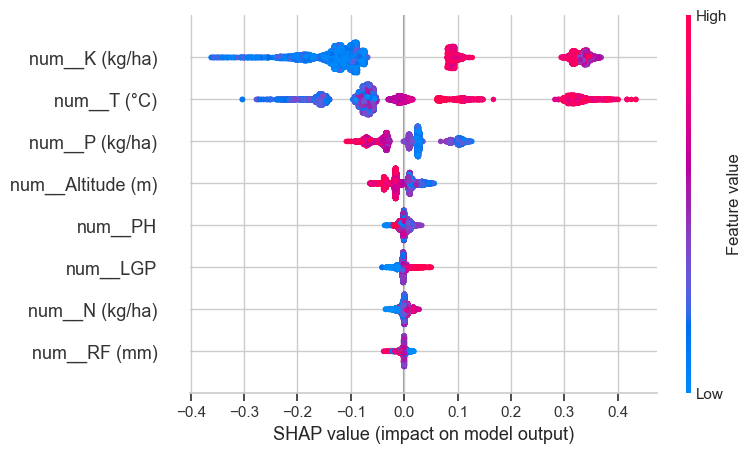

Displaying SHAP summary plot for class: Teff


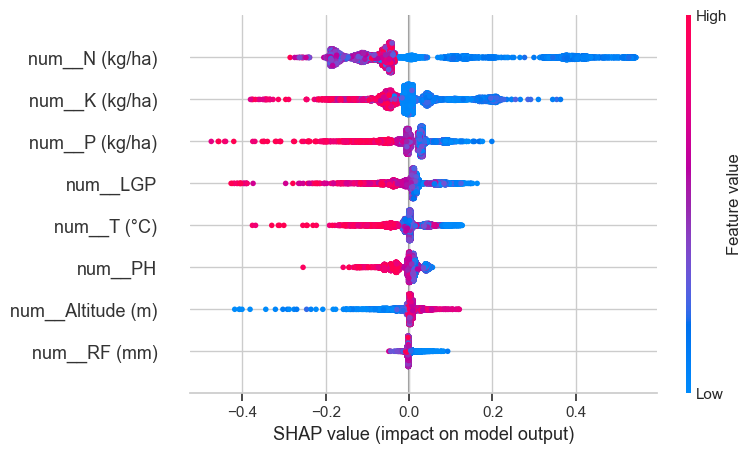

Displaying SHAP summary plot for class: Wheat


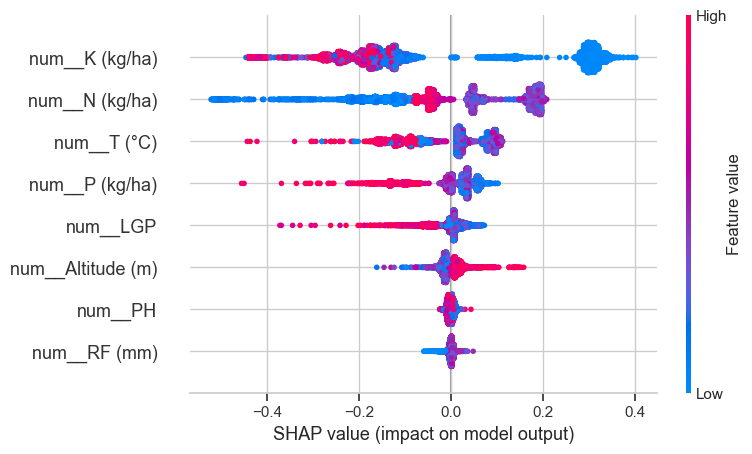

In [54]:
# ============================================
# SHAP SUMMARY PLOTS FOR ALL CLASSES
# ============================================

# Determine if shap_values is a list (one per class) or 3D array
if isinstance(shap_values, list):
    for class_index, class_name in enumerate(label_encoder.classes_):
        print(f"Displaying SHAP summary plot for class: {class_name}")
        shap.summary_plot(
            shap_values[class_index],
            X_test_transformed_df,
            feature_names=feature_names,
            show=True
        )
else:
    if len(shap_values.shape) == 3:  # (samples, features, classes)
        n_classes = shap_values.shape[2]
        for class_index, class_name in enumerate(label_encoder.classes_):
            print(f"Displaying SHAP summary plot for class: {class_name}")
            shap.summary_plot(
                shap_values[:, :, class_index],
                X_test_transformed_df,
                feature_names=feature_names,
                show=True
            )
    else:
        # Single-class SHAP (already handled)
        shap.summary_plot(
            shap_values,
            X_test_transformed_df,
            feature_names=feature_names
        )

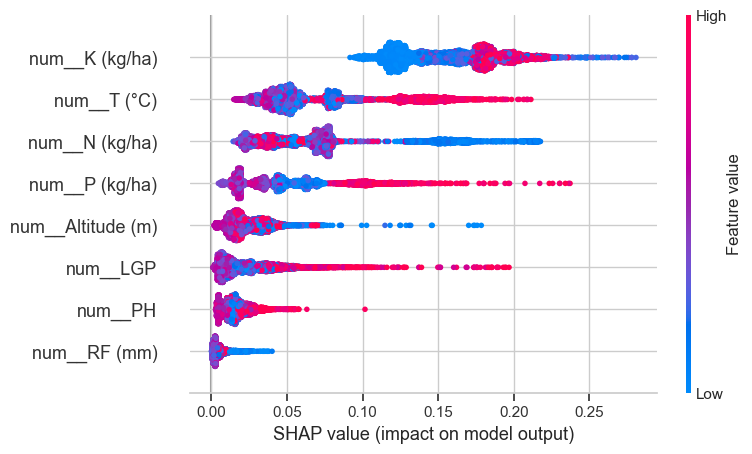

In [55]:
# ============================================
# SHAP SUMMARY PLOT - ALL CLASSES COMBINED
# ============================================

import numpy as np

# If shap_values is a list (one array per class), convert to 3D array
if isinstance(shap_values, list):
    # Stack to shape: (samples, features, classes)
    shap_values_array = np.stack(shap_values, axis=2)
else:
    shap_values_array = shap_values  # already 3D or 2D

# Compute mean absolute SHAP across classes: (samples, features)
mean_abs_shap_all_classes = np.mean(np.abs(shap_values_array), axis=2)

# Plot combined SHAP summary
shap.summary_plot(
    mean_abs_shap_all_classes,
    X_test_transformed_df,
    feature_names=feature_names,
    show=True
)

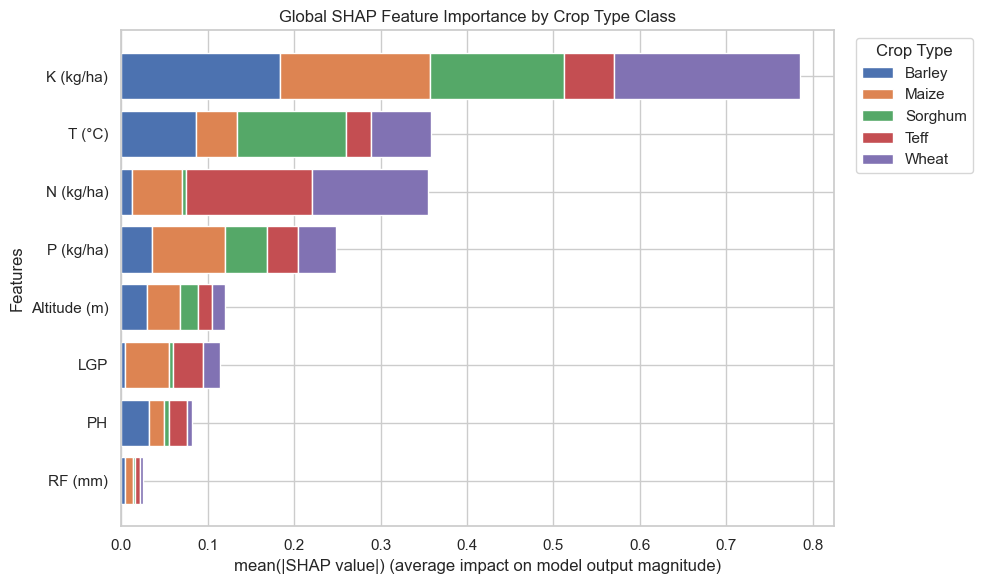

In [59]:
# ============================================
# FAST SHAP GLOBAL FEATURE IMPORTANCE
# WITH REAL CLASS NAMES
# ============================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------
# 1. Extract trained preprocessor and classifier
# --------------------------------------------
preprocessor_rf = best_rf_model.named_steps["preprocessor"]
model_rf = best_rf_model.named_steps["classifier"]

# --------------------------------------------
# 2. Transform test data
# --------------------------------------------
X_test_transformed = preprocessor_rf.transform(X_test)

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=numeric_features
)

# --------------------------------------------
# 3. Use only a sample for faster SHAP execution
# --------------------------------------------
sample_size = min(200, len(X_test_transformed_df))   # adjust to 100 if still slow
X_shap_sample = X_test_transformed_df.sample(
    n=sample_size,
    random_state=RANDOM_STATE
)

# --------------------------------------------
# 4. Compute SHAP values using TreeExplainer
# --------------------------------------------
explainer = shap.TreeExplainer(model_rf)
shap_values = explainer.shap_values(X_shap_sample)

# --------------------------------------------
# 5. Handle multiclass SHAP output
# --------------------------------------------
# shap_values is usually a list: one array per class
# each array shape: (samples, features)

class_names = list(label_encoder.classes_)

mean_abs_shap_by_class = []

if isinstance(shap_values, list):
    for class_idx in range(len(shap_values)):
        class_importance = np.abs(shap_values[class_idx]).mean(axis=0)
        mean_abs_shap_by_class.append(class_importance)

    mean_abs_shap_by_class = np.array(mean_abs_shap_by_class)  # shape: (classes, features)

else:
    # fallback for newer SHAP output formats
    shap_array = np.array(shap_values)

    if shap_array.ndim == 3:
        # expected shape could be (samples, features, classes)
        mean_abs_shap_by_class = np.abs(shap_array).mean(axis=0).T
    else:
        raise ValueError("Unexpected SHAP output shape for multiclass classification.")

# --------------------------------------------
# 6. Create DataFrame for plotting
# --------------------------------------------
shap_importance_df = pd.DataFrame(
    mean_abs_shap_by_class.T,
    index=numeric_features,
    columns=class_names
)

# Sort features by total importance across all classes
shap_importance_df["Total"] = shap_importance_df.sum(axis=1)
shap_importance_df = shap_importance_df.sort_values("Total", ascending=True)
shap_importance_df = shap_importance_df.drop(columns="Total")

# --------------------------------------------
# 7. Plot stacked horizontal bar chart
# --------------------------------------------
plt.figure(figsize=(10, 6))

left = np.zeros(len(shap_importance_df))

for crop_class in shap_importance_df.columns:
    plt.barh(
        shap_importance_df.index,
        shap_importance_df[crop_class],
        left=left,
        label=crop_class
    )
    left += shap_importance_df[crop_class].values

plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
plt.ylabel("Features")
plt.title("Global SHAP Feature Importance by Crop Type Class")
plt.legend(title="Crop Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [58]:
# ============================================
# SHAP GLOBAL FEATURE IMPORTANCE - BAR PLOT
# ============================================

import shap
import numpy as np
import pandas as pd

# Extract trained components from the final selected Random Forest pipeline
preprocessor_rf = best_rf_model.named_steps["preprocessor"]
model_rf = best_rf_model.named_steps["classifier"]

# Transform test data using the trained preprocessor
X_test_transformed = preprocessor_rf.transform(X_test)

# Convert transformed data to DataFrame
X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=numeric_features
)

# Initialize SHAP explainer for Random Forest probabilities
explainer = shap.Explainer(model_rf.predict_proba, X_test_transformed_df)

# Compute SHAP values
shap_values = explainer(X_test_transformed_df)

# --------------------------------------------
# Handle multiclass SHAP output
# --------------------------------------------
# Expected shape for multiclass:
# (samples, features, classes)

if hasattr(shap_values, "values"):
    shap_array = shap_values.values
else:
    raise ValueError("SHAP output does not contain .values attribute.")

# If output is 3D, average absolute SHAP across classes
if len(shap_array.shape) == 3:
    mean_abs_shap_all_classes = np.mean(np.abs(shap_array), axis=2)
else:
    mean_abs_shap_all_classes = np.abs(shap_array)

# --------------------------------------------
# Global SHAP bar plot
# --------------------------------------------
shap.summary_plot(
    mean_abs_shap_all_classes,
    X_test_transformed_df,
    feature_names=numeric_features,
    plot_type="bar",
    show=True
)

KeyboardInterrupt: 